In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = Path("..") / "backend" / "screen_time_mental_health.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [3]:
print("Rader, kolumner:", df.shape)
df.info()

Rader, kolumner: (4810, 10)
<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


In [4]:
print("Saknade värden per kolumn:")
print(df.isna().sum())

print("\nÄr subject_id unikt?", df["subject_id"].is_unique)
print("Antal dubblettrader:", df.duplicated().sum())

Saknade värden per kolumn:
subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64

Är subject_id unikt? True
Antal dubblettrader: 0


#### Kort översikt
- Datan har 4810 rader och 10 kolumner
- Inga saknade värden
- Inga dubbletter, och varje `subject_id` är unikt.
- `subject_id` är bara ett id-nummer(1, 2, 3...) och tas bort.
- `sex` är text och behöver göras om till siffror innan vi kan använda den i en modell.

In [5]:
df = df.drop(columns="subject_id")
df.head()

,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [6]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
screen_time_index,4810.0,3.22,1.03,1.00,2.33,3.00,4.00,6.00
est_leisure_screen_hours,4810.0,3.96,2.39,0.50,2.07,3.50,5.50,10.00
sleep_quality_index,4810.0,1.90,0.85,1.00,1.25,1.75,2.25,6.00
avg_sleep_hours,4810.0,7.69,1.27,1.36,7.05,7.87,8.54,12.21
midsleep_weekend_hours,4810.0,5.57,1.42,1.67,4.54,5.42,6.50,10.50
social_jetlag_hours,4810.0,2.40,1.14,-3.03,1.58,2.29,3.12,6.96
bdi_total,4810.0,7.27,7.70,0.00,2.00,5.00,10.00,51.00
depressed,4810.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00


In [7]:
print(df["sex"].value_counts())
print()
print(df["sex"].value_counts(normalize=True).round(3))

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

sex
Boy     0.509
Girl    0.491
Name: proportion, dtype: float64


#### Beskrivande statistik
- Eleverna sover i snitt 7,69 timmar per natt. Det Känns något lågt.
- `bdi_total` har medelvärde 7,27 men median 5. De flesta har låga poäng, men några få med höga poäng drar upp medelvärdet.
- Högsta `bdi_total` är 51, vilket räknas som svår depression. Ovanligt men rimligt, inget felvärde.
- Könsfördelningen är jämn: 2 446 pojkar (51 %) och 2 364 flickor (49 %).

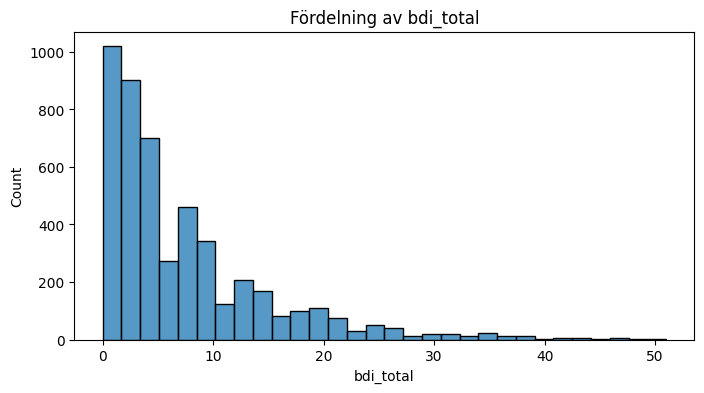

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["bdi_total"], bins=30)
plt.title("Fördelning av bdi_total")
plt.show()

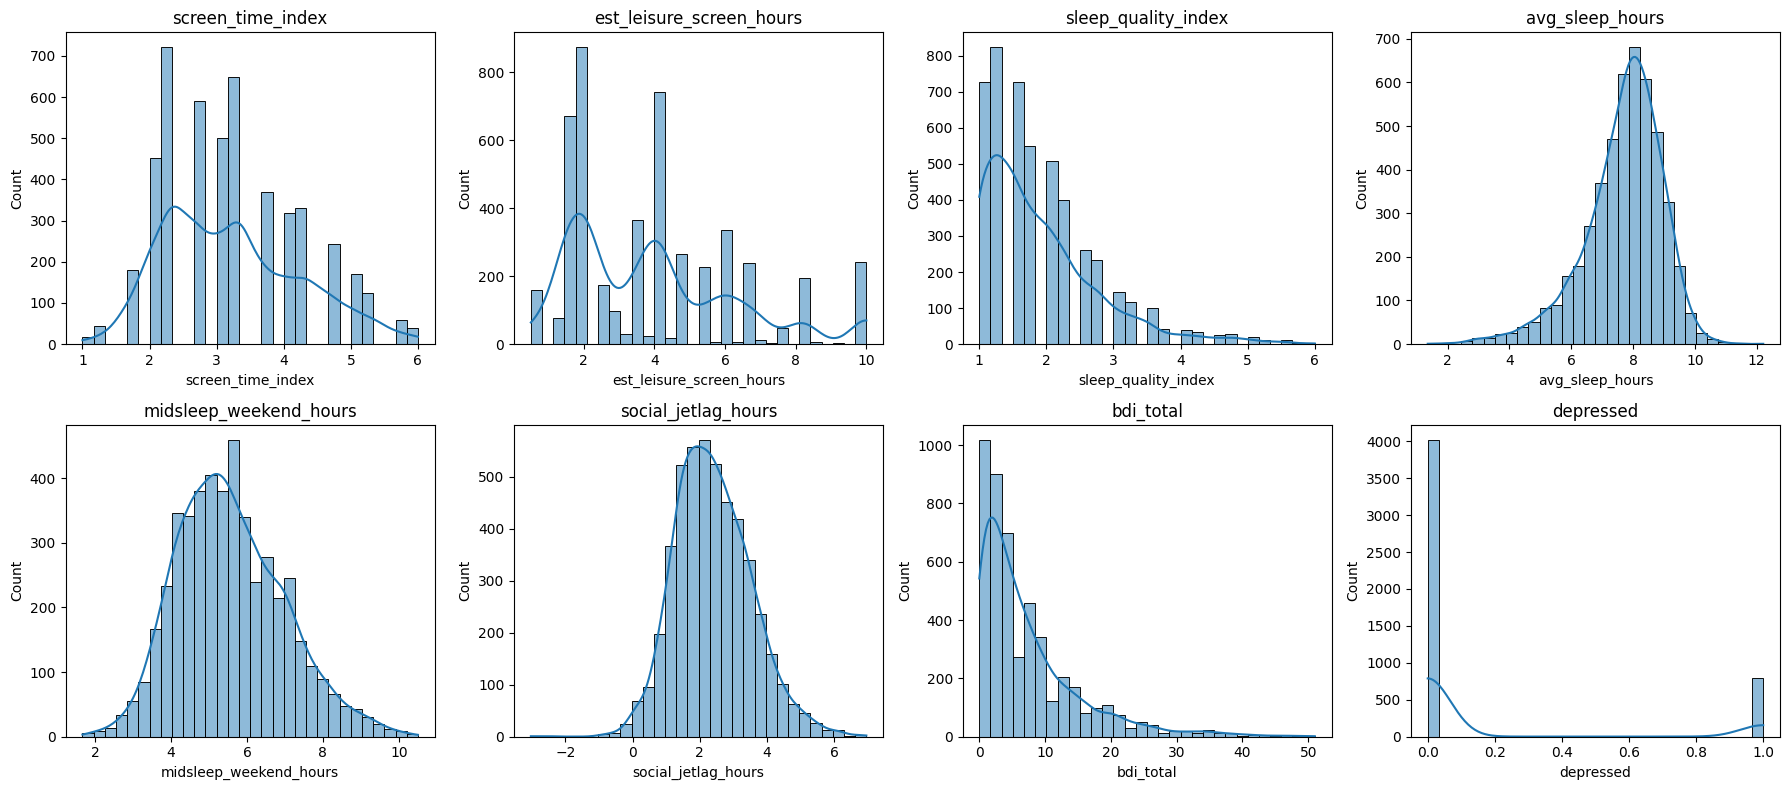

In [9]:
num_cols = df.select_dtypes("number").columns

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [10]:
df.groupby("sex").mean(numeric_only=True).round(2).T

sex,Boy,Girl
screen_time_index,3.21,3.23
est_leisure_screen_hours,4.00,3.92
sleep_quality_index,1.73,2.08
avg_sleep_hours,7.79,7.59
midsleep_weekend_hours,5.69,5.45
social_jetlag_hours,2.49,2.31
bdi_total,5.22,9.40
depressed,0.09,0.24


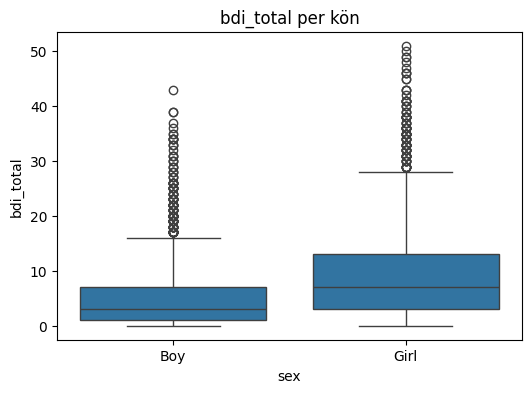

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="sex", y="bdi_total")
plt.title("bdi_total per kön")
plt.show()

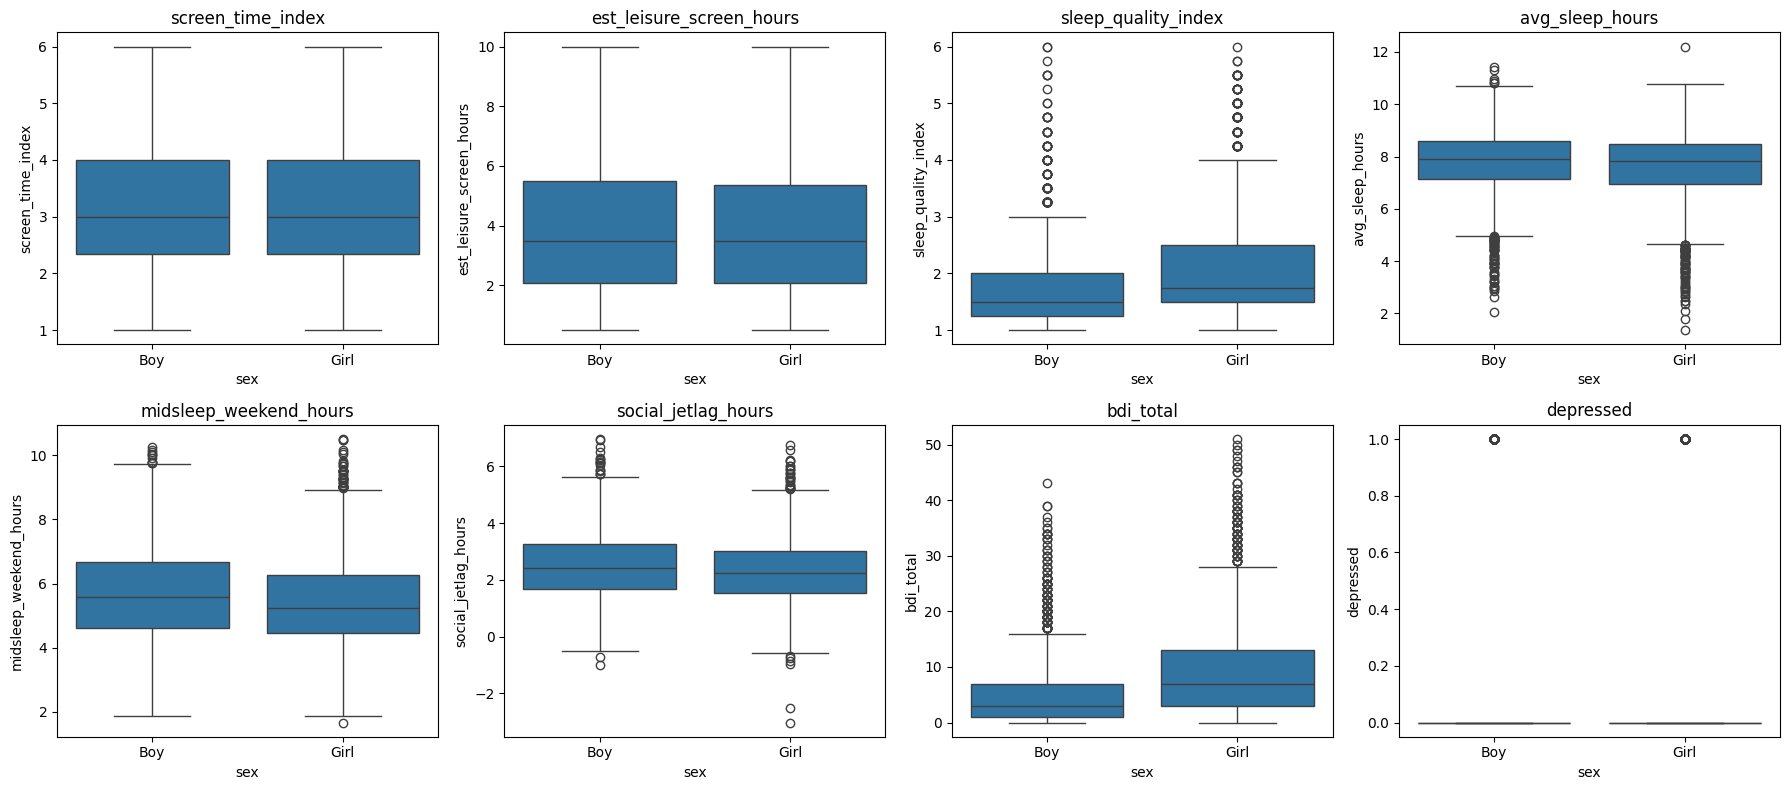

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x="sex", y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

#### Skillnader mellan könen
- Flickor har högre `bdi_total` (9,40) än pojkar (5,22), nästan dubbelt så högt.
- 24 % av flickorna är deprimerade jämfört med 9 % av pojkarna.
- Flickor sover sämre (`sleep_quality_index` 2,08 mot 1,73, högre = sämre) och något kortare (7,59 mot 7,79 timmar).
- Skärmtiden är nästan lika mellan könen.
- Det stämmer med studien: flickor mår sämre och sover sämre, trots ungefär lika mycket skärmtid.
- Kön verkar alltså vara en viktig variabel att ta ha med i vår modell.

In [13]:
df_corr = df.drop(columns="sex").copy()
df_corr["is_girl"] = (df["sex"] == "Girl").astype(int)
df_corr.head()

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed,is_girl
0,3.333,4.64,2.25,8.36,4.58,1.92,6,0,0
1,3.333,4.07,2.50,7.31,5.42,2.25,7,0,1
2,3.333,4.07,2.00,8.75,5.50,2.62,27,1,0
3,4.333,6.07,1.50,8.17,6.62,3.96,22,1,0
4,1.667,0.50,2.50,8.88,4.12,1.79,3,0,0


In [14]:
df_corr.corr()["bdi_total"].sort_values(ascending=False).round(2)

bdi_total                   1.00
depressed                   0.82
sleep_quality_index         0.38
is_girl                     0.27
midsleep_weekend_hours      0.15
screen_time_index           0.13
est_leisure_screen_hours    0.11
social_jetlag_hours         0.07
avg_sleep_hours            -0.26
Name: bdi_total, dtype: float64

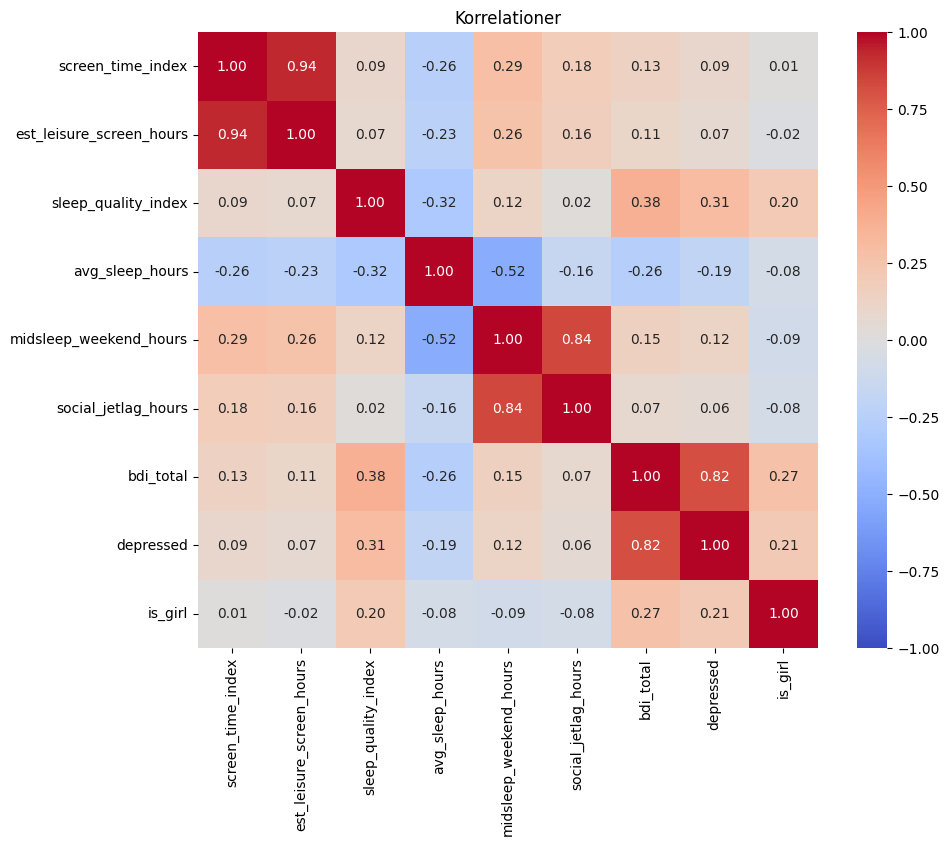

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korrelationer")
plt.show()

#### Korrelationer
- `sleep_quality_index` har starkast samband med `bdi_total` (0,38, måttligt positivt). Elever som sover sämre har fler depressiva symptom.
- `avg_sleep_hours` har −0,26 (svagt negativt). Elever som sover längre har färre symptom.
- Kön (`is_girl`, 0,27) hänger också ihop med depression: flickor har högre poäng.
- Skärmtid har bara ett svagt samband med `bdi_total` (0,11–0,13), men hänger ihop med kortare sömn. Det stämmer med studien, där skärmtid påverkar depression via sömnen.
- `depressed` (0,82) är skapad från `bdi_total` och får inte användas som feature (data leakage).
- `screen_time_index` och `est_leisure_screen_hours` (0,94) mäter nästan samma sak, liksom `midsleep_weekend_hours` och `social_jetlag_hours` (0,84). Välj bara en från varje par.
- Korrelation visar samband, inte orsak.

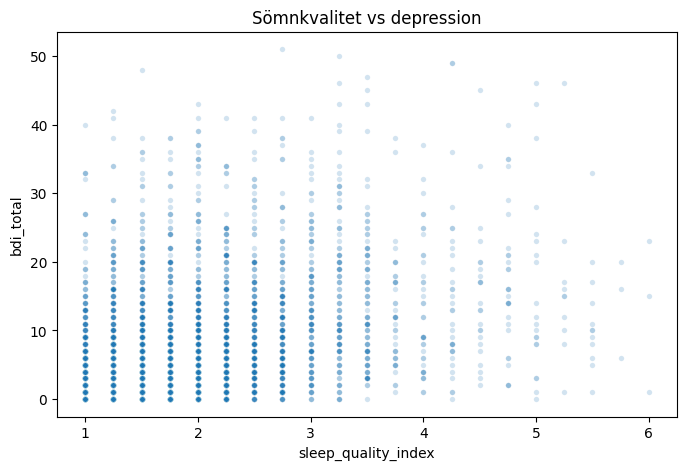

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="sleep_quality_index", y="bdi_total", alpha=0.2, s=15)
plt.title("Sömnkvalitet vs depression")
plt.show()

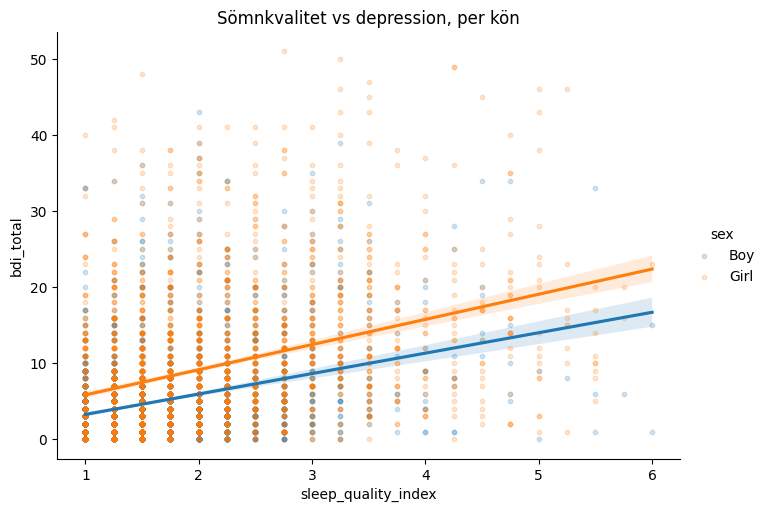

In [17]:
sns.lmplot(
    data=df, x="sleep_quality_index", y="bdi_total", hue="sex",
    scatter_kws={"alpha": 0.2, "s": 10}, height=5, aspect=1.4
)
plt.title("Sömnkvalitet vs depression, per kön")
plt.show()

In [18]:
df["sleep_group"] = pd.cut(
    df["avg_sleep_hours"],
    bins=[0, 6, 7, 8, 9, 13],
    labels=["<6 h", "6-7 h", "7-8 h", "8-9 h", ">9 h"],
)

df.groupby("sleep_group", observed=True).agg(
    antal=("bdi_total", "size"),
    bdi_medel=("bdi_total", "mean"),
    andel_deprimerade=("depressed", "mean"),
).round(2)

,antal,bdi_medel,andel_deprimerade
sleep_group,,,
<6 h,483,11.85,0.34
6-7 h,668,8.55,0.19
7-8 h,1505,7.59,0.18
8-9 h,1579,5.92,0.11
>9 h,575,4.82,0.09


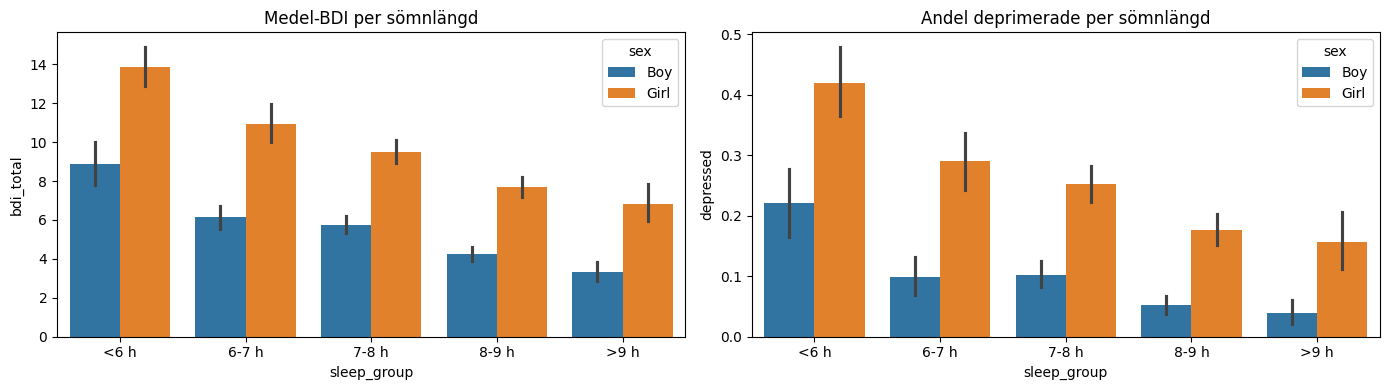

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=df, x="sleep_group", y="bdi_total", hue="sex", ax=axes[0])
axes[0].set_title("Medel-BDI per sömnlängd")

sns.barplot(data=df, x="sleep_group", y="depressed", hue="sex", ax=axes[1])
axes[1].set_title("Andel deprimerade per sömnlängd")

plt.tight_layout()
plt.show()

#### Samband i diagram
- Trendlinjerna lutar uppåt: sämre sömnkvalitet hänger ihop med högre `bdi_total`. Flickornas linje ligger högre och är lite brantare.
- Ju längre sömn, desto lägre medel-BDI: från 11,85 (<6 h) till 4,82 (>9 h).
- 34 % av de som sover under 6 timmar är deprimerade, jämfört med 9 % av de som sover över 9 timmar. Nästan fyra gånger så många.
- Mönstret gäller för både pojkar och flickor, men flickor ligger högre i varje sömngrupp (t.ex. 42 % mot 22 % bland de som sover under 6 h).
- Stapeldiagram är lättare att läsa än punktmoln när datan är stor. Punktmolnet visar däremot att spridningen är stor: sambandet gäller inte alla elever.

In [20]:
df["screen_group"] = df["screen_time_index"].round().astype(int)

df["screen_group"].value_counts().sort_index()

screen_group
1      62
2    1353
3    1740
4    1018
5     540
6      97
Name: count, dtype: int64

In [21]:
sleep_cols = ["avg_sleep_hours", "sleep_quality_index", "midsleep_weekend_hours", "bdi_total"]

df.groupby("screen_group")[sleep_cols].mean().round(2)

,avg_sleep_hours,sleep_quality_index,midsleep_weekend_hours,bdi_total
screen_group,,,,
1,8.02,2.00,4.85,6.03
2,8.01,1.81,5.16,5.90
3,7.80,1.89,5.43,7.24
4,7.45,1.96,5.93,8.16
5,7.17,2.01,6.23,8.76
6,6.38,2.26,6.82,10.16


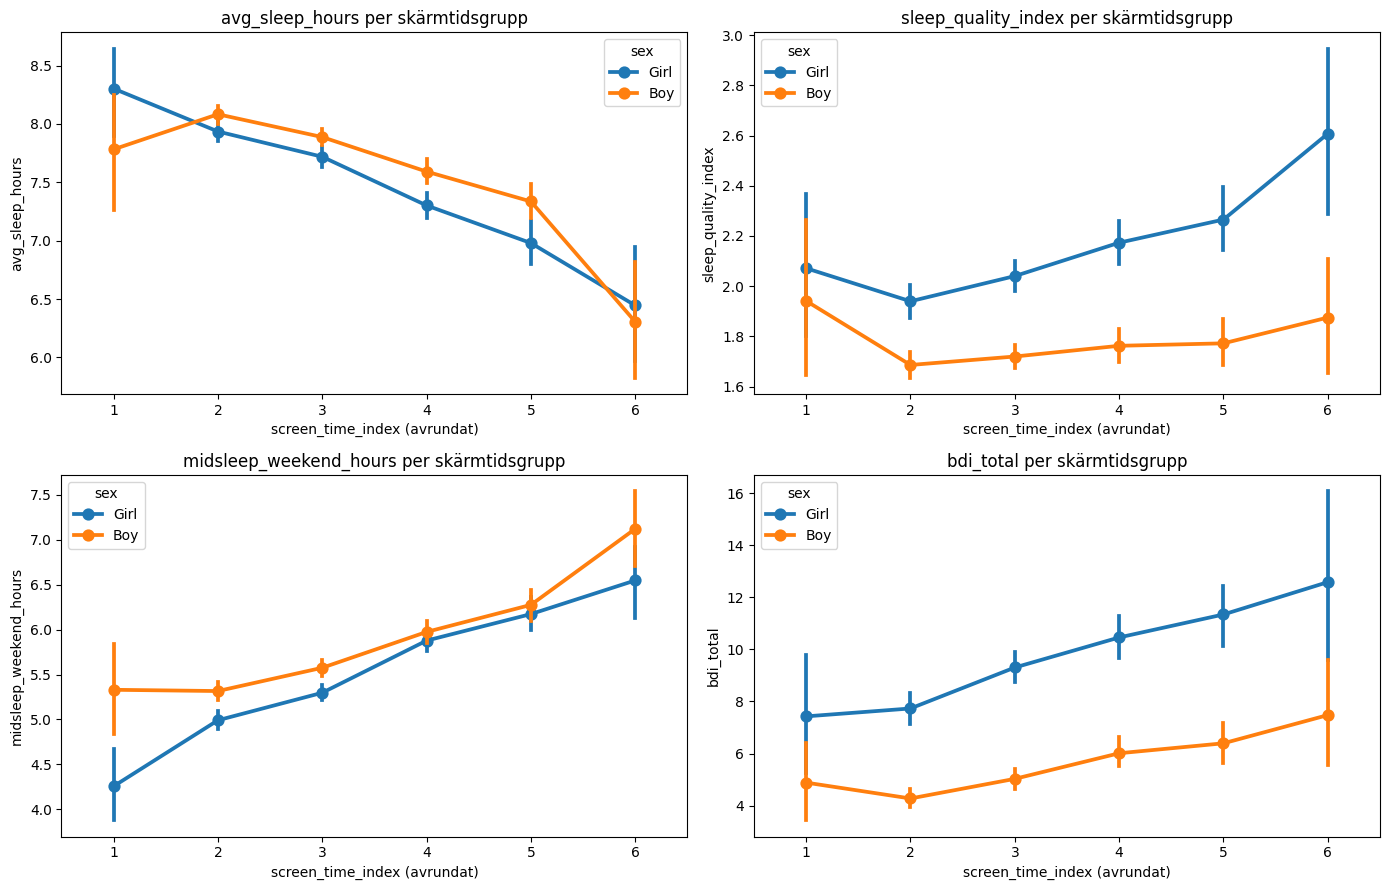

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, sleep_cols):
    sns.pointplot(data=df, x="screen_group", y=col, hue="sex", ax=ax)
    ax.set_title(f"{col} per skärmtidsgrupp")
    ax.set_xlabel("screen_time_index (avrundat)")

plt.tight_layout()
plt.show()

In [23]:
corr_cols = ["screen_time_index"] + sleep_cols

for sex, group in df.groupby("sex"):
    print(sex)
    print(group[corr_cols].corr()["screen_time_index"].drop("screen_time_index").round(2))
    print()

Boy
avg_sleep_hours          -0.24
sleep_quality_index       0.04
midsleep_weekend_hours    0.26
bdi_total                 0.14
Name: screen_time_index, dtype: float64

Girl
avg_sleep_hours          -0.27
sleep_quality_index       0.14
midsleep_weekend_hours    0.32
bdi_total                 0.14
Name: screen_time_index, dtype: float64



#### Skärmtid och sömn
- Mer skärmtid hänger ihop med kortare sömn: från 8,02 h (minst skärmtid) till 6,38 h (mest), ungefär 1 h 40 min skillnad.
- Mer skärmtid hänger ihop med senare sömn på helger: midsleep går från ca kl. 05 till ca kl. 07.
- Skärmtid och sömnkvalitet: svagt samband för flickor (0,14), nästan inget för pojkar (0,04). Stämmer med studien.
- Grupp 1 och 6 har få elever (62 och 97), så deras medelvärden är osäkrare.
- Datan passar med kedjan skärmtid - sömn - depression, men eftersom vi bara har en mätning per elev kan vi inte visa vad som orsakar vad.

In [24]:
q1 = df["bdi_total"].quantile(0.25)
q3 = df["bdi_total"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("25 %:", q1, " 75 %:", q3, " IQR:", iqr)
print("Nedre gräns:", lower, " Övre gräns:", upper)
print("Antal extremvärden:", ((df["bdi_total"] < lower) | (df["bdi_total"] > upper)).sum())

25 %: 2.0  75 %: 10.0  IQR: 8.0
Nedre gräns: -10.0  Övre gräns: 22.0
Antal extremvärden: 257


In [25]:
def count_outliers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n = ((s < lower) | (s > upper)).sum()
    return round(lower, 2), round(upper, 2), n


check_cols = [c for c in num_cols if c != "depressed"]

rows = []
for col in check_cols:
    lower, upper, n = count_outliers(df[col])
    rows.append({
        "kolumn": col,
        "nedre_gräns": lower,
        "övre_gräns": upper,
        "antal": n,
        "andel_%": round(100 * n / len(df), 1),
        "min": df[col].min(),
        "max": df[col].max(),
    })

pd.DataFrame(rows)

,kolumn,nedre_gräns,övre_gräns,antal,andel_%,min,max
0,screen_time_index,-0.17,6.50,0,0.0,1.00,6.00
1,est_leisure_screen_hours,-3.08,10.64,0,0.0,0.50,10.00
2,sleep_quality_index,-0.25,3.75,175,3.6,1.00,6.00
3,avg_sleep_hours,4.82,10.77,164,3.4,1.36,12.21
4,midsleep_weekend_hours,1.60,9.44,37,0.8,1.67,10.50
5,social_jetlag_hours,-0.73,5.43,54,1.1,-3.03,6.96
6,bdi_total,-10.00,22.00,257,5.3,0.00,51.00


In [26]:
print("Kortast sömn:")
display(df.nsmallest(5, "avg_sleep_hours"))

print("Högst BDI:")
display(df.nlargest(5, "bdi_total"))

Kortast sömn:


,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed,sleep_group,screen_group
693,Girl,5.667,8.21,3.25,1.36,8.38,1.88,46,1,<6 h,6
4270,Girl,3.333,4.07,4.25,1.77,6.25,-0.21,25,1,<6 h,3
4556,Boy,3.667,7.57,2.75,2.05,8.75,3.08,28,1,<6 h,4
4357,Girl,3.000,3.50,2.50,2.07,8.33,2.25,41,1,<6 h,3
4098,Girl,2.333,1.50,2.50,2.36,6.54,1.38,9,0,<6 h,2


Högst BDI:


,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed,sleep_group,screen_group
2557,Girl,5.000,6.79,2.75,7.00,6.83,3.00,51,1,6-7 h,5
4478,Girl,2.667,3.50,3.25,8.88,8.08,5.33,50,1,8-9 h,3
3526,Girl,2.333,1.50,4.25,7.90,4.29,1.21,49,1,7-8 h,2
4675,Girl,3.333,4.07,4.25,6.64,4.21,1.04,49,1,6-7 h,3
1532,Girl,2.667,2.93,1.50,7.90,5.21,1.96,48,1,7-8 h,3


#### Extremvärden
- `bdi_total` har flest extremvärden (257 st, 5,3 %), eftersom den är mest högerskev. Alla ligger på den övre sidan (över 22 poäng).
- `screen_time_index` och `est_leisure_screen_hours` har inga extremvärden, eftersom de är skalor med fasta min- och maxvärden (1–6 och max 10 timmar).
- Kortaste sömnen är 1,36 timmar i snitt per natt, vilket är orimligt och troligen ett svarsfel. Elevens övriga värden (mycket skärmtid, dålig och sen sömn, BDI 46) passar ändå ihop.
- Eleverna med högst BDI (48–51) har svår depression. Det är ovanligt men äkta värden inom skalan (0–63).
- **Beslut:** Vi behåller extremvärdena. De är riktiga elever, och tar vi bort dem försvinner de med svårast depression. Ett fåtal misstänkta sömnvärden noteras.